In [12]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import ttest_ind
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import joblib
import os

# Enable inline plotting for Jupyter Notebook
%matplotlib inline

In [13]:
# Define paths for pre-trained models and cleaned datasets
MODELS_DIR = "../Pre-Trained Models"
os.makedirs(MODELS_DIR, exist_ok=True)

stock_files_dict = {
    'AAPL': '../Cleaned Data/apple_cleaned_dataset.csv',
    'AMZN': '../Cleaned Data/amazon_cleaned_dataset.csv',
    'GOOGL': '../Cleaned Data/google_cleaned_dataset.csv',
    'JPM': '../Cleaned Data/jpm_cleaned_dataset.csv',
    'META': '../Cleaned Data/meta_cleaned_dataset.csv',
    'MSFT': '../Cleaned Data/msft_cleaned_dataset.csv',
    'NVDA': '../Cleaned Data/nvda_cleaned_dataset.csv',
    'TSLA': '../Cleaned Data/tesla_cleaned_dataset.csv',
    'V': '../Cleaned Data/v_cleaned_dataset.csv',
    'WMT': '../Cleaned Data/wmt_cleaned_dataset.csv'
}

# Load models
stock_models = {}
stock_predictions = {}

for stock_name, file_path in stock_files_dict.items():
    try:
        model_path = os.path.join(MODELS_DIR, f"{stock_name}_model.pkl")
        stock_models[stock_name] = joblib.load(model_path)
        print(f"Loaded pre-trained model for {stock_name}")

        df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
        df['MA_10'] = df['Close'].rolling(10).mean()
        df['MA_50'] = df['Close'].rolling(50).mean()
        df['Next_Close'] = df['Close'].shift(-1)
        df.dropna(inplace=True)

        X_test = df[['Close', 'MA_10', 'MA_50']]
        y_test = df['Next_Close']
        stock_predictions[stock_name] = (X_test, y_test)

    except FileNotFoundError:
        print(f"No pre-trained model found for {stock_name}, skipping...")

No pre-trained model found for AAPL, skipping...
No pre-trained model found for AMZN, skipping...
No pre-trained model found for GOOGL, skipping...
Loaded pre-trained model for JPM
Loaded pre-trained model for META
Loaded pre-trained model for MSFT
Loaded pre-trained model for NVDA
No pre-trained model found for TSLA, skipping...
Loaded pre-trained model for V
Loaded pre-trained model for WMT


In [14]:
def evaluate_model(stock_name):
    """Evaluate the model performance."""
    model = stock_models[stock_name]
    X_test, y_test = stock_predictions[stock_name]
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    direction_acc = np.mean(np.sign(y_pred) == np.sign(y_test.diff().fillna(0))) * 100

    print(f"\nEvaluation for {stock_name}:")
    print(f"- Mean Absolute Error: ${mae:.2f}")
    print(f"- Root Mean Squared Error: ${rmse:.2f}")
    print(f"- Direction Accuracy: {direction_acc:.1f}%")

    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, y_pred, label='Predicted', alpha=0.7)
    plt.title(f'{stock_name} - Actual vs Predicted Prices')
    plt.legend()
    plt.show()

In [15]:
def walk_forward_test(stock_name):
    """Perform a walk-forward validation test."""
    model = stock_models[stock_name]
    X_test, y_test = stock_predictions[stock_name]

    predictions = []
    actual_values = []

    for i in range(len(X_test)):
        features = X_test.iloc[[i]]
        true_value = y_test.iloc[i]

        try:
            predicted_value = model.predict(features)[0]
            predictions.append(predicted_value)
            actual_values.append(true_value)
        except Exception as e:
            print(f"Error in walk-forward testing {stock_name}: {str(e)}")

    mae = mean_absolute_error(actual_values, predictions)
    rmse = np.sqrt(mean_squared_error(actual_values, predictions))

    print(f"\nWalk-forward Validation for {stock_name}:")
    print(f"- Mean Absolute Error: ${mae:.2f}")
    print(f"- Root Mean Squared Error: ${rmse:.2f}")

    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index[:len(predictions)], actual_values, label="Actual")
    plt.plot(y_test.index[:len(predictions)], predictions, label="Predicted", alpha=0.7)
    plt.title(f'{stock_name} Walk-forward Validation')
    plt.legend()
    plt.show()

In [16]:
def live_validation(stock_name):
    """Perform live validation using recent market data."""
    try:
        ticker = stock_name.upper()
        end_date = datetime.today().date()
        start_date = end_date - timedelta(days=30)

        data = yf.download(ticker, start=start_date, end=end_date)
        if data.empty or 'Close' not in data.columns:
            print(f"No recent data available for {stock_name}.")
            return

        data['MA_10'] = data['Close'].rolling(10).mean()
        data['MA_50'] = data['Close'].rolling(50).mean()
        data.dropna(inplace=True)

        X_live = data[['Close', 'MA_10', 'MA_50']]
        model = stock_models[stock_name]
        predictions = model.predict(X_live)

        plt.figure(figsize=(12, 6))
        plt.plot(data.index, data['Close'], label="Actual Close Price")
        plt.plot(data.index, predictions, label="Predicted Price", alpha=0.7)
        plt.title(f'{stock_name} Live Validation')
        plt.legend()
        plt.show()

    except Exception as e:
        print(f"Error in live validation for {stock_name}: {str(e)}")

In [17]:
def check_significance(stock_name):
    """Perform a statistical significance test (T-test)."""
    try:
        X_test, y_test = stock_predictions[stock_name]
        model = stock_models[stock_name]

        predicted_values = model.predict(X_test)
        actual_values = y_test.values

        t_stat, p_value = ttest_ind(predicted_values, actual_values, equal_var=False)

        print(f"\nT-Test Results for {stock_name}:")
        print(f"- t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

        if p_value < 0.05:
            print("🔍 Model predictions differ significantly from actual values (p < 0.05)")
        else:
            print("✅ Model predictions are statistically similar to actual values (p > 0.05)")

    except Exception as e:
        print(f"Error in statistical significance testing for {stock_name}: {str(e)}")


Available models: ['JPM', 'META', 'MSFT', 'NVDA', 'V', 'WMT']

Processing JPM...

Evaluation for JPM:
- Mean Absolute Error: $1.49
- Root Mean Squared Error: $1.94
- Direction Accuracy: 50.9%


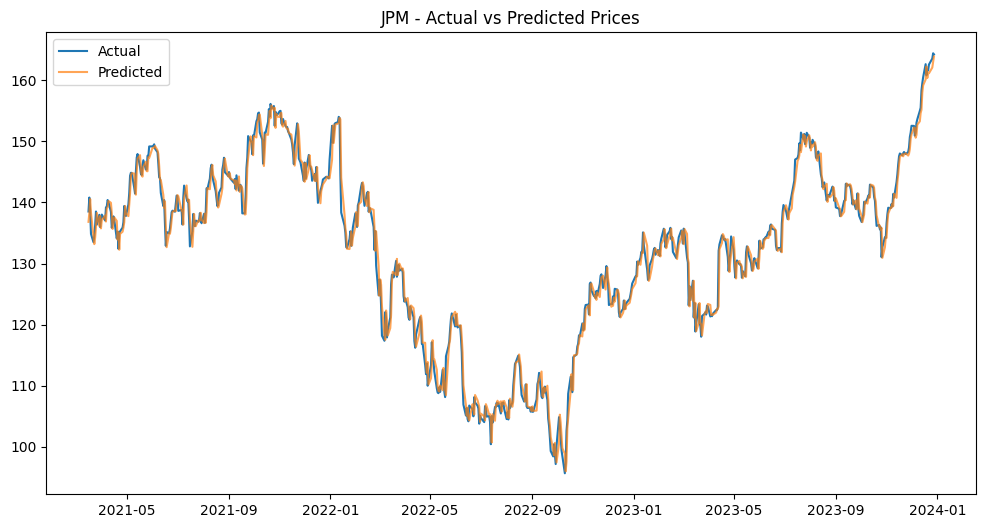


Walk-forward Validation for JPM:
- Mean Absolute Error: $1.49
- Root Mean Squared Error: $1.94


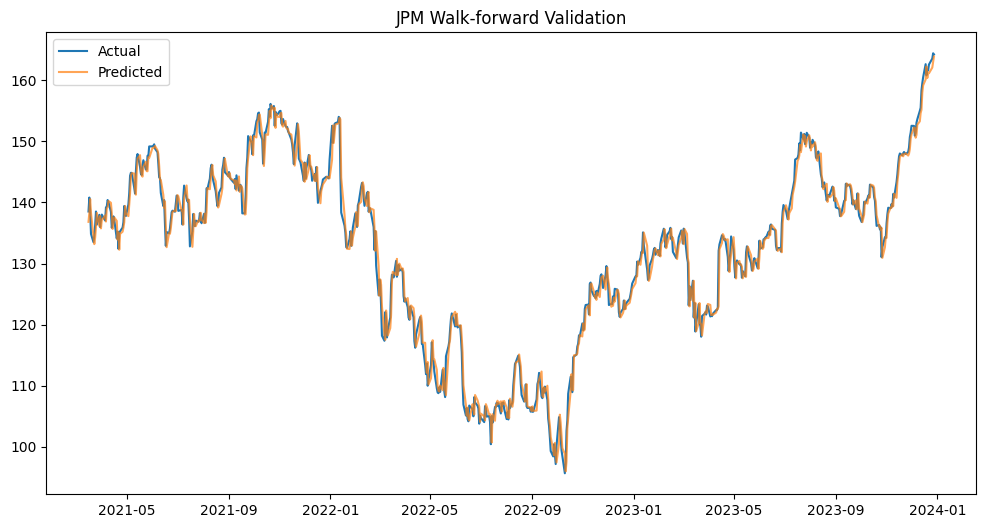

[*********************100%***********************]  1 of 1 completed
e:\Simple Stock Predication AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Error in live validation for JPM: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LinearRegression.

T-Test Results for JPM:
- t-statistic: -0.0960, p-value: 0.9235
✅ Model predictions are statistically similar to actual values (p > 0.05)

Processing META...

Evaluation for META:
- Mean Absolute Error: $4.50
- Root Mean Squared Error: $6.74
- Direction Accuracy: 50.6%


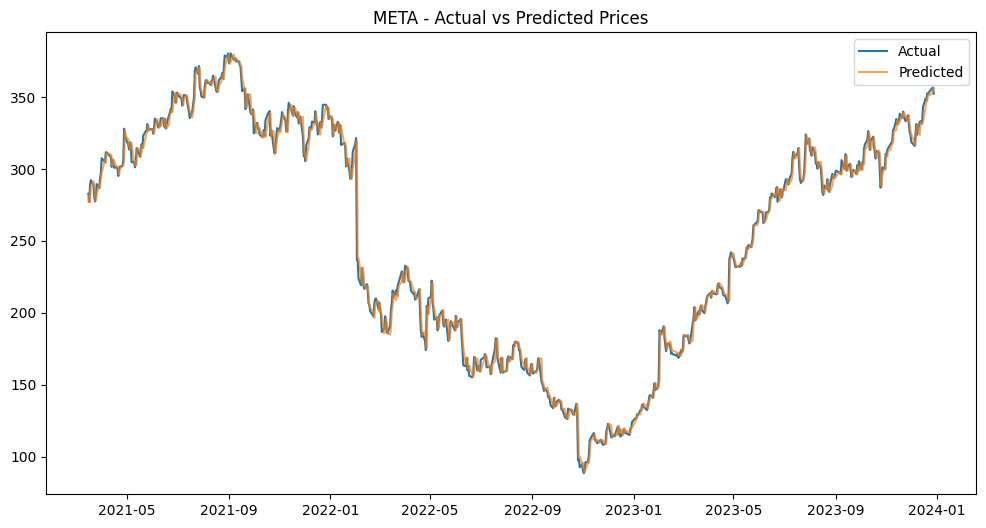


Walk-forward Validation for META:
- Mean Absolute Error: $4.50
- Root Mean Squared Error: $6.74


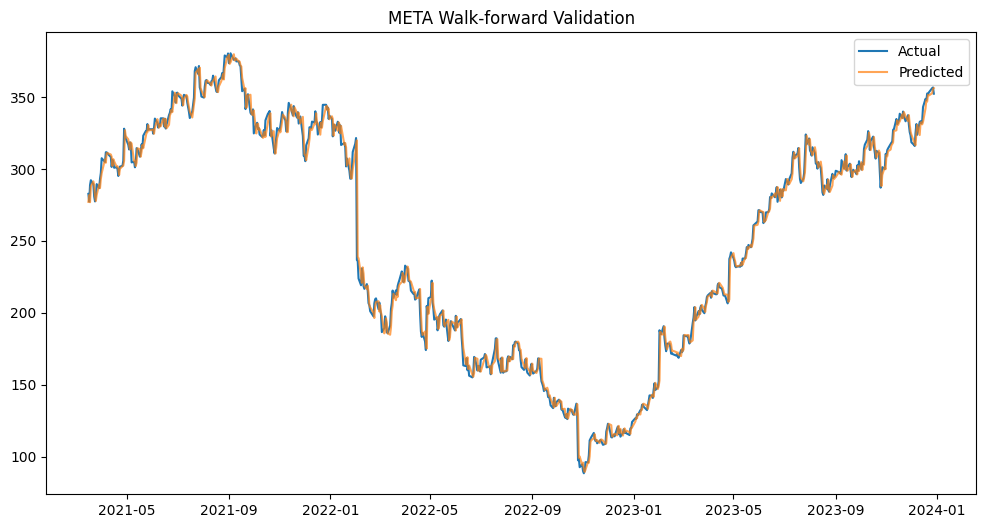

[*********************100%***********************]  1 of 1 completed
e:\Simple Stock Predication AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Error in live validation for META: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LinearRegression.

T-Test Results for META:
- t-statistic: -0.0355, p-value: 0.9717
✅ Model predictions are statistically similar to actual values (p > 0.05)

Processing MSFT...

Evaluation for MSFT:
- Mean Absolute Error: $3.69
- Root Mean Squared Error: $4.83
- Direction Accuracy: 51.2%


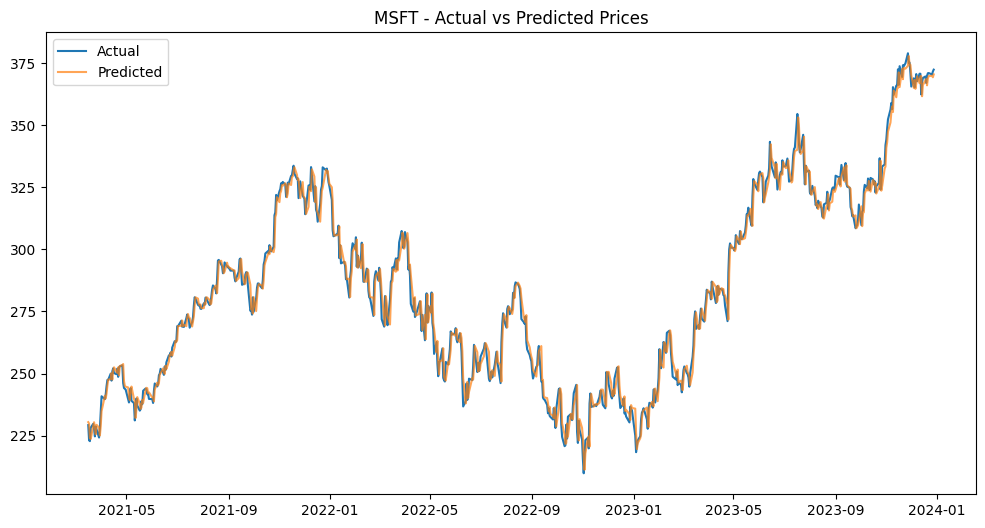


Walk-forward Validation for MSFT:
- Mean Absolute Error: $3.69
- Root Mean Squared Error: $4.83


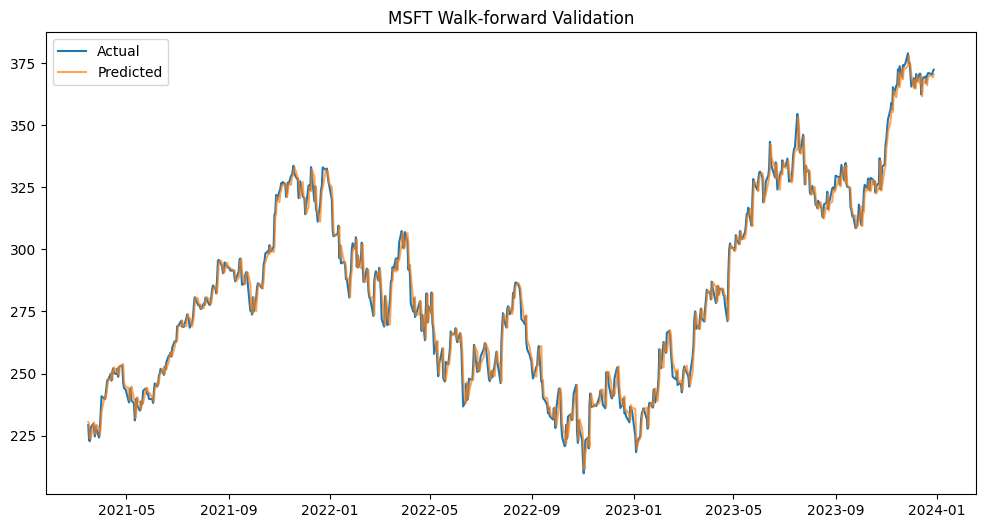

[*********************100%***********************]  1 of 1 completed
e:\Simple Stock Predication AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Error in live validation for MSFT: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LinearRegression.

T-Test Results for MSFT:
- t-statistic: -0.1036, p-value: 0.9175
✅ Model predictions are statistically similar to actual values (p > 0.05)

Processing NVDA...

Evaluation for NVDA:
- Mean Absolute Error: $0.61
- Root Mean Squared Error: $0.84
- Direction Accuracy: 53.1%


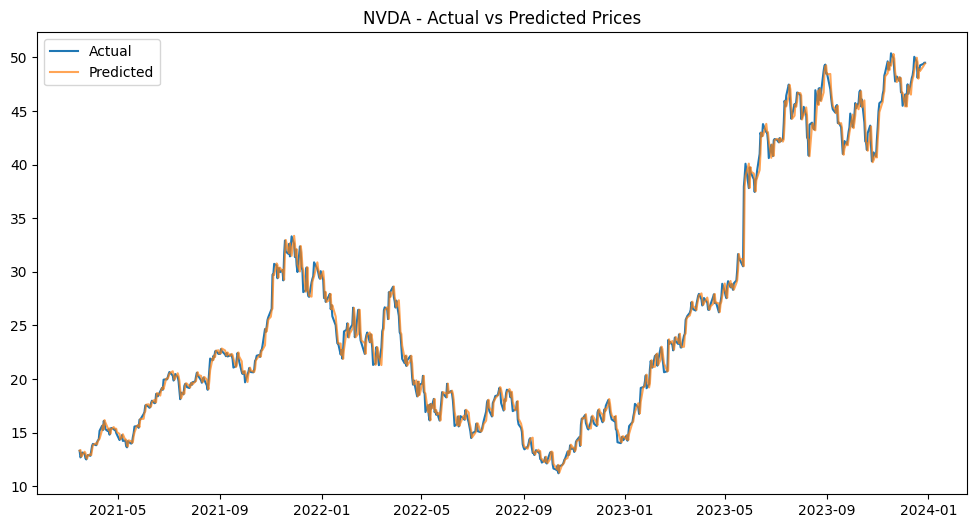


Walk-forward Validation for NVDA:
- Mean Absolute Error: $0.61
- Root Mean Squared Error: $0.84


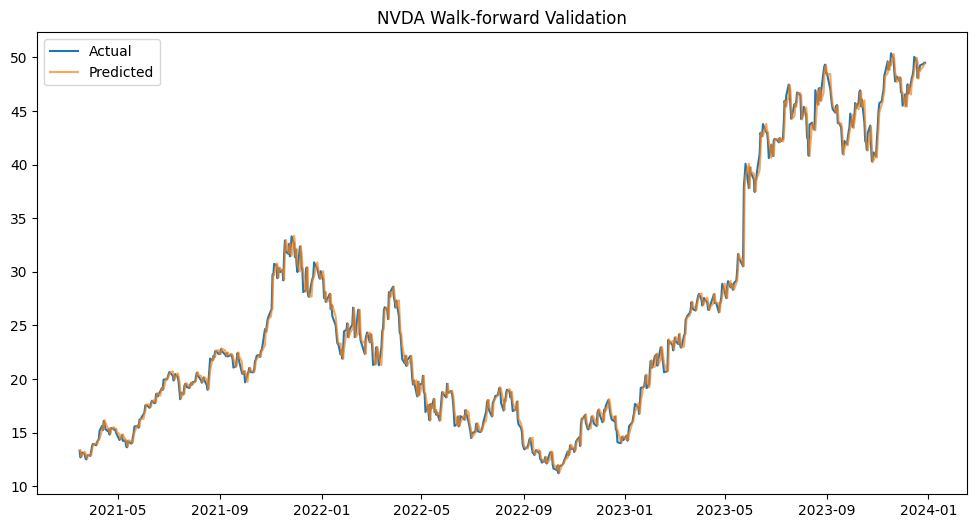

[*********************100%***********************]  1 of 1 completed
e:\Simple Stock Predication AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Error in live validation for NVDA: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LinearRegression.

T-Test Results for NVDA:
- t-statistic: -0.0447, p-value: 0.9643
✅ Model predictions are statistically similar to actual values (p > 0.05)

Processing V...

Evaluation for V:
- Mean Absolute Error: $2.36
- Root Mean Squared Error: $3.19
- Direction Accuracy: 51.8%


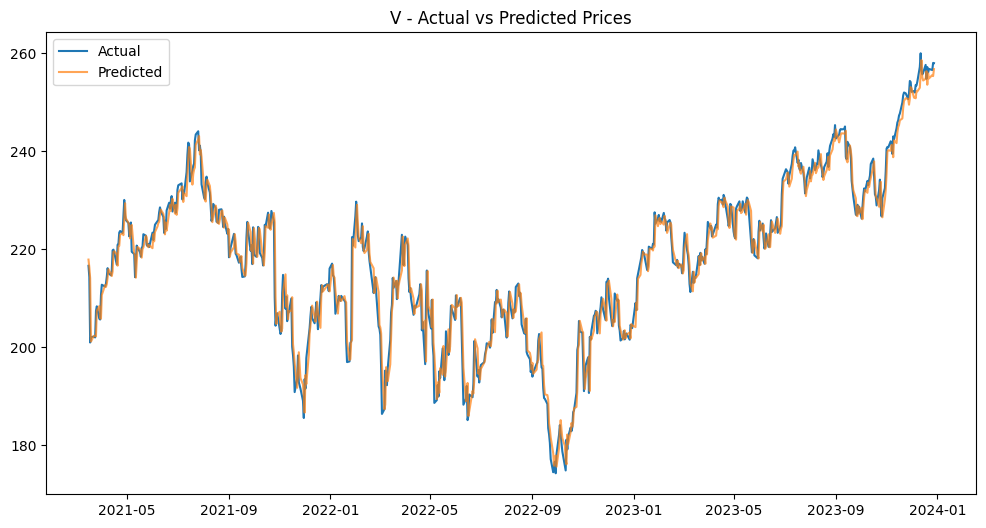


Walk-forward Validation for V:
- Mean Absolute Error: $2.36
- Root Mean Squared Error: $3.19


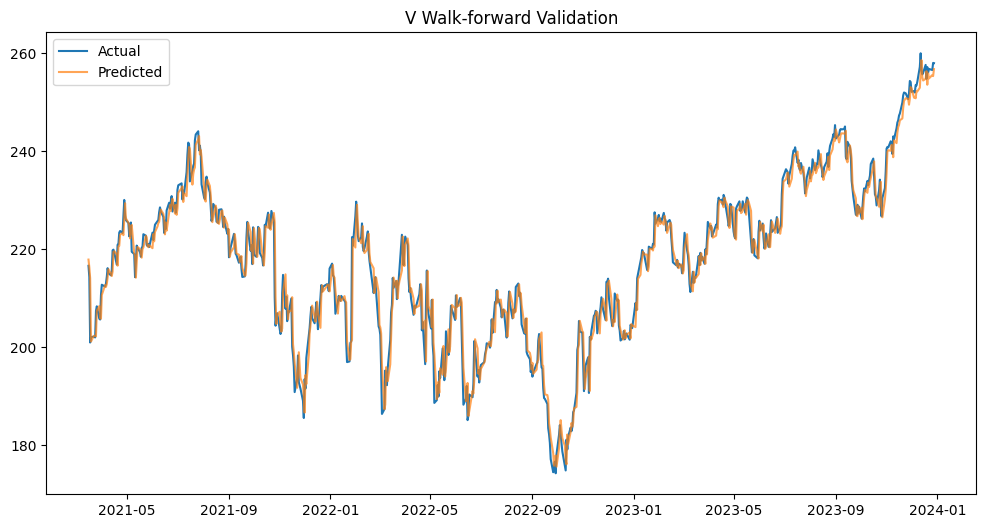

[*********************100%***********************]  1 of 1 completed

Error in live validation for V: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LinearRegression.

T-Test Results for V:
- t-statistic: -0.2153, p-value: 0.8296
✅ Model predictions are statistically similar to actual values (p > 0.05)

Processing WMT...

Evaluation for WMT:
- Mean Absolute Error: $0.41
- Root Mean Squared Error: $0.59
- Direction Accuracy: 54.2%



e:\Simple Stock Predication AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


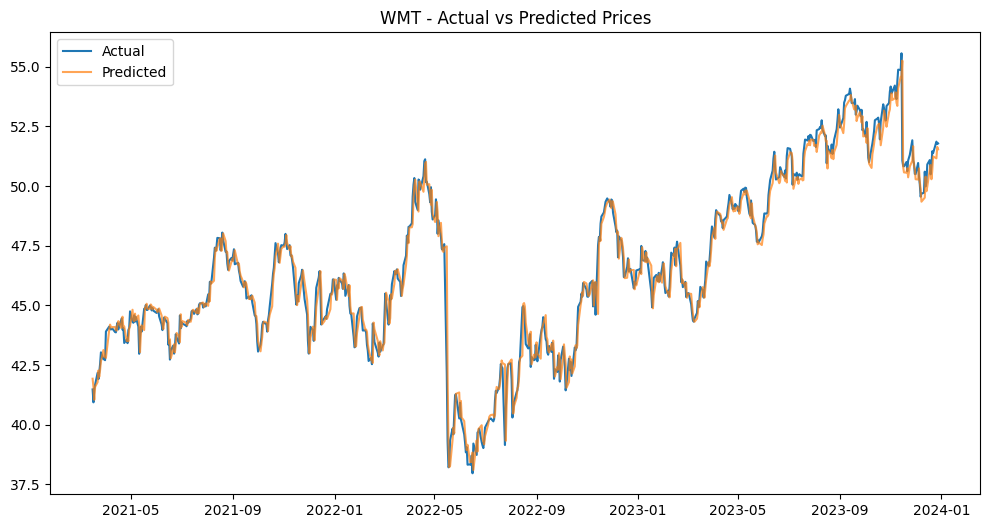


Walk-forward Validation for WMT:
- Mean Absolute Error: $0.41
- Root Mean Squared Error: $0.59


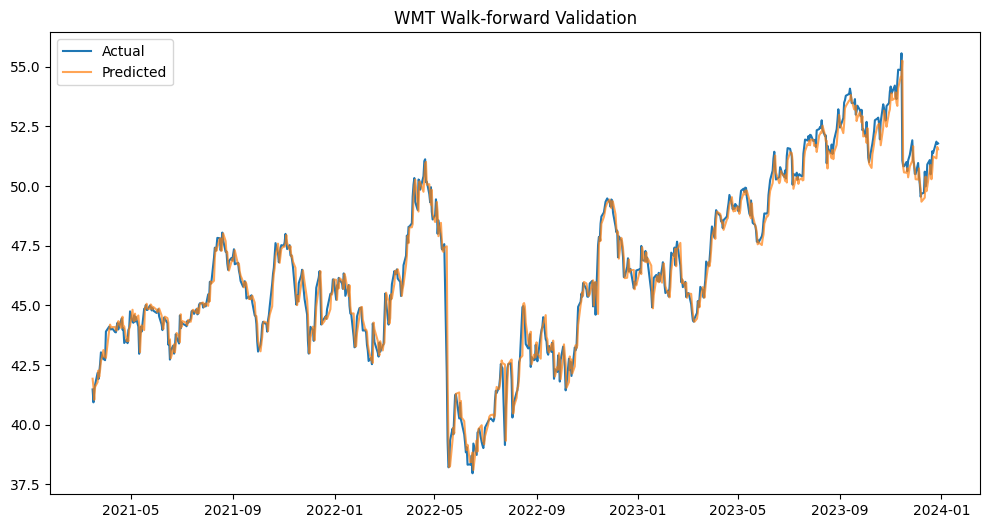

[*********************100%***********************]  1 of 1 completed

Error in live validation for WMT: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LinearRegression.

T-Test Results for WMT:
- t-statistic: -0.2514, p-value: 0.8015
✅ Model predictions are statistically similar to actual values (p > 0.05)



e:\Simple Stock Predication AI\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
if not stock_models:
    print("No models loaded! Please check your model files.")
else:
    print("\nAvailable models:", list(stock_models.keys()))

    for stock_name in stock_models.keys():
        print(f"\nProcessing {stock_name}...")
        evaluate_model(stock_name)
        walk_forward_test(stock_name)
        live_validation(stock_name)
        check_significance(stock_name)